# Extra: Segmentação Além do RFM (O que aconteceria se...?)

Neste notebook experimental, vamos expandir nossa visão. Até agora, olhamos apenas para o comportamento financeiro (RFM). 

**O Desafio:** E se incluíssemos a **Sensibilidade a Descontos** e a **Idade** dos clientes? 
Será que descobriríamos que os nossos 'Campeões' são mais velhos? Ou que os clientes em risco só compram quando há promoção?

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Carregando a base completa (com idade e desconto)
df = pd.read_csv('../data/df_clientes_header.csv')

# Preparando a Recência como fizemos no Notebook 02
data_hoje = pd.to_datetime('2026-06-01')
df['Recencia'] = (data_hoje - pd.to_datetime(df['data_da_ultima_compra'])).dt.days

df.head(3)

,cliente_id,avg_desconto,tempo_atividade_dias,propensao_promo,mes_pico_compra,valor_total,data_da_ultima_compra,idade,tenure_dias,qtde_compras,cat_Escrita,cat_Papelaria,cat_Sem_istórico,Recencia
0,CUST-1000,0.631429,73.0,0.0,4.0,500.67,2026-05-21,61,491,7,True,False,False,11.0
1,CUST-1001,-0.230000,79.0,0.0,3.0,700.57,2026-05-19,29,819,8,True,False,False,13.0
2,CUST-1002,-1.855000,68.0,0.0,5.0,246.12,2026-05-14,20,700,6,True,False,False,18.0


### 1. Seleção de Atributos para o Experimento

Vamos selecionar o RFM tradicional + `idade` + `avg_desconto`. 
Isso nos dará uma segmentação **Psicográfica e Comportamental** ao mesmo tempo.

In [14]:
features = ['Recencia', 'qtde_compras', 'valor_total', 'idade', 'avg_desconto']
df_spinoff = df[features].copy()

# Renomeando para facilitar a leitura
df_spinoff.columns = ['Recencia', 'Frequencia', 'Monetario', 'Idade', 'Sensibilidade_Desconto']
df_spinoff = df_spinoff.dropna()

df_spinoff.describe()

,Recencia,Frequencia,Monetario,Idade,Sensibilidade_Desconto
count,499.000000,499.000000,499.000000,499.000000,499.000000
mean,19.356713,5.356713,560.165491,43.567134,0.114772
std,15.984964,2.380689,393.556549,14.933218,1.700059
min,3.000000,1.000000,4.920000,18.000000,-8.150000
25%,7.000000,4.000000,223.265000,31.000000,-0.578000
50%,14.000000,5.000000,518.310000,43.000000,0.056667
75%,28.000000,7.000000,793.115000,55.000000,0.915417
max,83.000000,15.000000,2116.040000,70.000000,11.240000


### 2. Preparação e Escalonamento

Como estamos lidando com variáveis de escalas muito diferentes (Idade vai de 18 a 70, Monetário vai aos milhares), o escalonamento é crítico.

In [15]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_spinoff)

df_scaled = pd.DataFrame(df_scaled, columns=df_spinoff.columns)
print("Dados escalonados com sucesso.")

Dados escalonados com sucesso.


### 3. O Método do Cotovelo para 5 Variáveis

Ao adicionar mais variáveis, a complexidade aumenta. Vamos verificar se o número ideal de clusters ainda é 3.

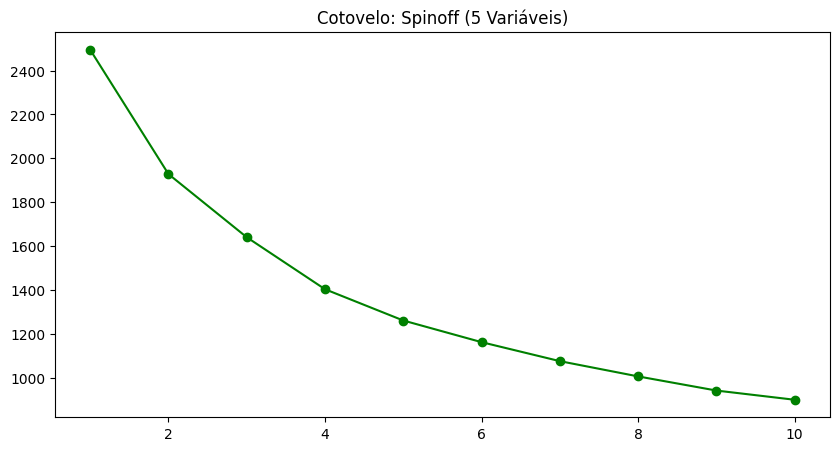

In [16]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, 'go-')
plt.title('Cotovelo: Spinoff (5 Variáveis)')
plt.show()

### 4. Treinamento e Análise das Novas Personas

Vamos rodar o modelo e observar como o `avg_desconto` e a `idade` distribuem os clientes. 
Fique atento ao grupo que possui o maior `Sensibilidade_Desconto`!

In [17]:
kmeans_spinoff = KMeans(n_clusters=4, random_state=42, n_init=10) # Testando com 4 grupos
df_spinoff['Cluster'] = kmeans_spinoff.fit_predict(df_scaled)

resumo_spinoff = df_spinoff.groupby('Cluster').mean().round(2)
resumo_spinoff['contagem'] = df_spinoff.groupby('Cluster')['Recencia'].count()

resumo_spinoff

,Recencia,Frequencia,Monetario,Idade,Sensibilidade_Desconto,contagem
Cluster,,,,,,
0,13.27,8.28,1085.55,47.52,-0.04,106
1,13.90,5.29,520.66,30.17,-0.15,163
2,15.19,4.69,401.13,57.57,0.21,150
3,46.35,2.86,242.72,39.38,0.67,80


### 5. O que a história nos diz agora?

Com essas novas variáveis, podemos encontrar perfis como:

1.  **O Jovem Caçador de Ofertas:** Idade baixa, ticket médio baixo, mas alta sensibilidade a desconto.
2.  **O Veterano Fiel:** Idade alta, compra preços cheios, alta frequência.
3.  **O VIP Sensível:** Gasta muito, mas só compra quando recebe um mimo ou desconto exclusivo.

**Ação de Negócio:** Se descobrirmos que os 'Campeões' têm baixa sensibilidade a desconto, o marketing pode parar de enviar cupons para eles e salvar margem de lucro imediatamente!